In [ ]:
# PYTHONPATH=src python3 -m mitochime.deep_learning.train_deep \ 
#   --mode cnn \
#   --train-tsv data/processed/PAIR_train_seq_L150.tsv \
#   --test-tsv  data/processed/PAIR_test_seq_L150.tsv \
#   --L 150 --epochs 30 --batch 128 --lr 0.001 \
#   --seed 42 \
#   --select-best-by f1 \
#   --weight-decay 1e-4 \
#   --out-dir models/deep/cnn_final_L150_seed42 \
#   --reports-dir reports/deep/cnn_final_L150_seed42 \
#   --save-predictions

In [51]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------
CV_BASE    = Path("../reports/deep/cnn_cv30_L150_seed42")
FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")  # update this

FOLDS = [0, 1, 2, 3, 4]

print("CV_BASE exists:", CV_BASE.exists(), CV_BASE)
print("FINAL_BASE exists:", FINAL_BASE.exists(), FINAL_BASE)

CV_BASE exists: True ../reports/deep/cnn_cv30_L150_seed42
FINAL_BASE exists: True ../reports/deep/cnn_final_L150_seed42_fixedep25


## cross fold

In [55]:
rows = []
for k in FOLDS:
    p = CV_BASE / f"fold{k}" / "cnn_metrics.json"
    d = json.loads(p.read_text())
    rows.append({
        "fold": k,
        "loss": d["test_loss"],
        "acc": d["accuracy"],
        "prec": d["precision"],
        "rec": d["recall"],
        "f1": d["f1"],
        "auc": d["roc_auc"],
        "n": d["n"],
        "n_pos": d["n_pos"],
        "n_neg": d["n_neg"],
    })

cv_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
cv_df

,fold,loss,acc,prec,rec,f1,auc,n,n_pos,n_neg
0,0,0.413652,0.884531,0.850670,0.932813,0.889849,0.946674,6400,3200,3200
1,1,0.447483,0.868594,0.822532,0.940000,0.877352,0.938873,6400,3200,3200
2,2,0.469630,0.851875,0.793688,0.950937,0.865226,0.928304,6400,3200,3200
3,3,0.412574,0.873906,0.834498,0.932813,0.880921,0.938488,6400,3200,3200
4,4,0.478812,0.853079,0.805736,0.930625,0.863689,0.927179,6398,3200,3198


In [56]:
metrics = ["loss", "acc", "prec", "rec", "f1", "auc"]
cv_summary = pd.DataFrame({
    "metric": metrics,
    "mean": [cv_df[m].mean() for m in metrics],
    "std":  [cv_df[m].std(ddof=1) for m in metrics],
})
cv_summary

,metric,mean,std
0,loss,0.444430,0.030776
1,acc,0.866397,0.013949
2,prec,0.821425,0.022599
3,rec,0.937438,0.008337
4,f1,0.875407,0.010997
5,auc,0.935903,0.008145


In [54]:
cv_df.to_csv(CV_BASE / "cnn_cv30_folds.tsv", sep="\t", index=False)
cv_summary.to_csv(CV_BASE / "cnn_cv30_summary.tsv", sep="\t", index=False)
print("Saved:",
      CV_BASE / "cnn_cv30_folds.tsv",
      CV_BASE / "cnn_cv30_summary.tsv")

Saved: ../reports/deep/cnn_cv30_L150_seed42/cnn_cv30_folds.tsv ../reports/deep/cnn_cv30_L150_seed42/cnn_cv30_summary.tsv


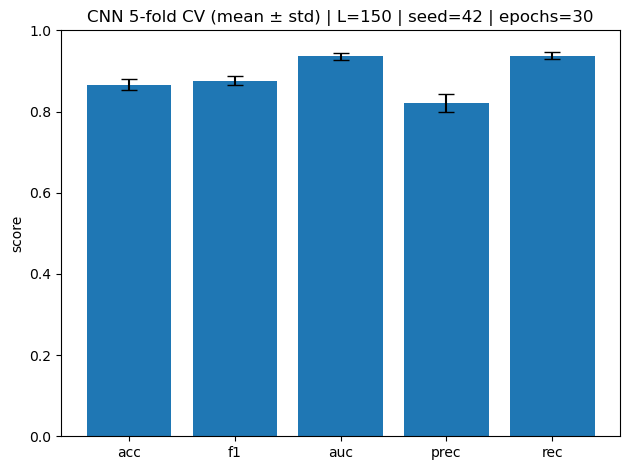

In [57]:
plot_metrics = ["acc", "f1", "auc", "prec", "rec"]
means = [cv_df[m].mean() for m in plot_metrics]
stds  = [cv_df[m].std(ddof=1) for m in plot_metrics]

plt.figure()
plt.bar(plot_metrics, means, yerr=stds, capsize=6)
plt.ylim(0, 1.0)
plt.title("CNN 5-fold CV (mean ± std) | L=150 | seed=42 | epochs=30")
plt.ylabel("score")
plt.tight_layout()
plt.show()

In [58]:
logs = []
for k in FOLDS:
    p = CV_BASE / f"fold{k}" / "cnn_training_log.tsv"
    log = pd.read_csv(p, sep="\t")
    log["fold"] = k
    logs.append(log)

log_df = pd.concat(logs, ignore_index=True)

grp = log_df.groupby("epoch", as_index=False).agg(
    train_loss_mean=("train_loss", "mean"),
    train_loss_std=("train_loss", "std"),
    val_loss_mean=("test_loss", "mean"),
    val_loss_std=("test_loss", "std"),
    val_f1_mean=("test_f1", "mean"),
    val_f1_std=("test_f1", "std"),
    val_auc_mean=("test_auc", "mean"),
    val_auc_std=("test_auc", "std"),
)

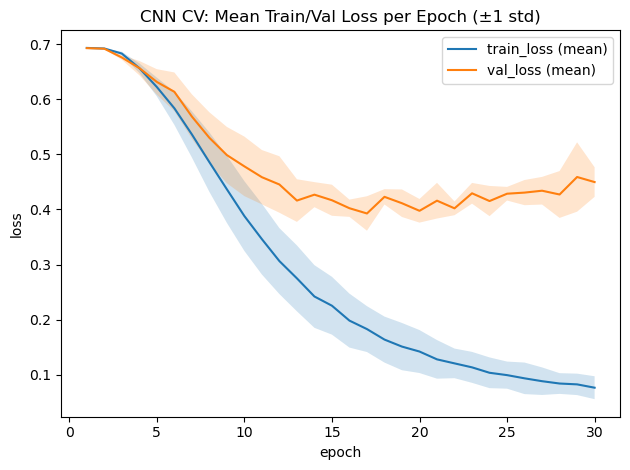

In [59]:
plt.figure()
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")
plt.fill_between(
    grp["epoch"],
    grp["train_loss_mean"] - grp["train_loss_std"],
    grp["train_loss_mean"] + grp["train_loss_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_loss_mean"] - grp["val_loss_std"],
    grp["val_loss_mean"] + grp["val_loss_std"],
    alpha=0.2
)
plt.title("CNN CV: Mean Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

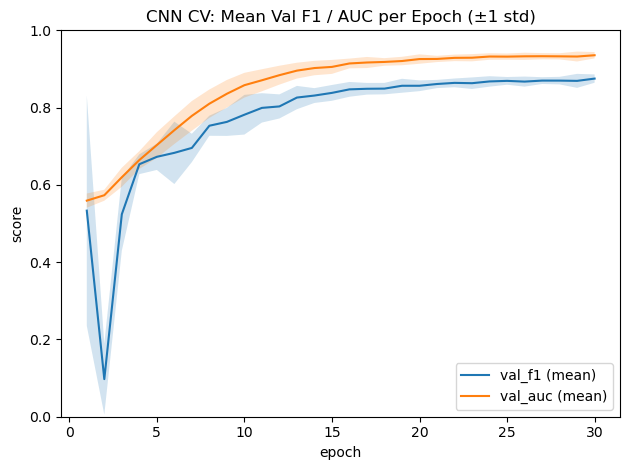

In [60]:
plt.figure()
plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["val_auc_mean"], label="val_auc (mean)")
plt.fill_between(
    grp["epoch"],
    grp["val_f1_mean"] - grp["val_f1_std"],
    grp["val_f1_mean"] + grp["val_f1_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_auc_mean"] - grp["val_auc_std"],
    grp["val_auc_mean"] + grp["val_auc_std"],
    alpha=0.2
)
plt.title("CNN CV: Mean Val F1 / AUC per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("score")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

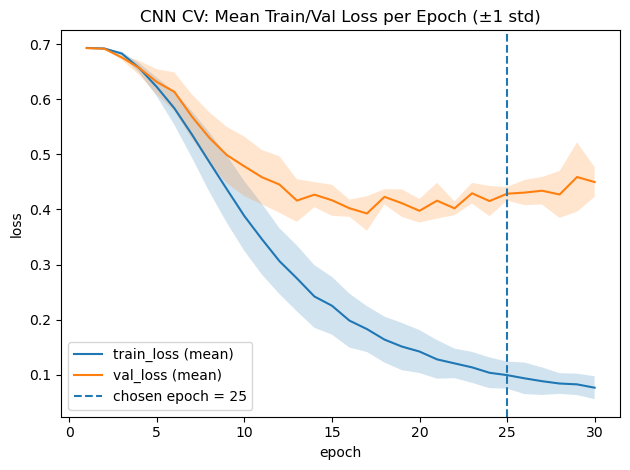

In [69]:
chosen_epoch = 25

plt.figure()
plt.plot(grp["epoch"], grp["train_loss_mean"], label="train_loss (mean)")
plt.plot(grp["epoch"], grp["val_loss_mean"], label="val_loss (mean)")
plt.fill_between(
    grp["epoch"],
    grp["train_loss_mean"] - grp["train_loss_std"],
    grp["train_loss_mean"] + grp["train_loss_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_loss_mean"] - grp["val_loss_std"],
    grp["val_loss_mean"] + grp["val_loss_std"],
    alpha=0.2
)
plt.axvline(chosen_epoch, linestyle="--", label=f"chosen epoch = {chosen_epoch}")
plt.title("CNN CV: Mean Train/Val Loss per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

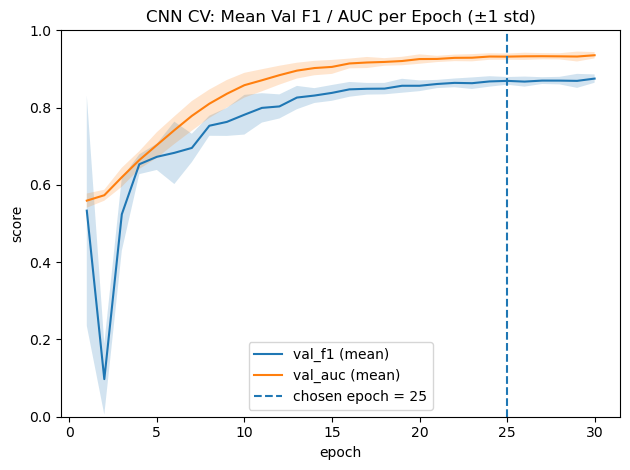

In [70]:
plt.figure()
plt.plot(grp["epoch"], grp["val_f1_mean"], label="val_f1 (mean)")
plt.plot(grp["epoch"], grp["val_auc_mean"], label="val_auc (mean)")
plt.fill_between(
    grp["epoch"],
    grp["val_f1_mean"] - grp["val_f1_std"],
    grp["val_f1_mean"] + grp["val_f1_std"],
    alpha=0.2
)
plt.fill_between(
    grp["epoch"],
    grp["val_auc_mean"] - grp["val_auc_std"],
    grp["val_auc_mean"] + grp["val_auc_std"],
    alpha=0.2
)
plt.axvline(chosen_epoch, linestyle="--", label=f"chosen epoch = {chosen_epoch}")
plt.title("CNN CV: Mean Val F1 / AUC per Epoch (±1 std)")
plt.xlabel("epoch")
plt.ylabel("score")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

## held out test

In [ ]:
FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")

In [73]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FINAL_BASE = Path("../reports/deep/cnn_final_L150_seed42_fixedep25")

final = json.loads((FINAL_BASE / "cnn_metrics.json").read_text())

final_row = pd.DataFrame([{
    "loss": final["test_loss"],
    "acc": final["accuracy"],
    "prec": final["precision"],
    "rec": final["recall"],
    "f1": final["f1"],
    "auc": final["roc_auc"],
}])

final_row.round(4)

,loss,acc,prec,rec,f1,auc
0,0.3034,0.9092,0.8724,0.9588,0.9135,0.9607


In [74]:
final_row.to_csv(FINAL_BASE / "cnn_final_test_metrics.tsv", sep="\t", index=False)
print("Saved:", FINAL_BASE / "cnn_final_test_metrics.tsv")

Saved: ../reports/deep/cnn_final_L150_seed42_fixedep25/cnn_final_test_metrics.tsv


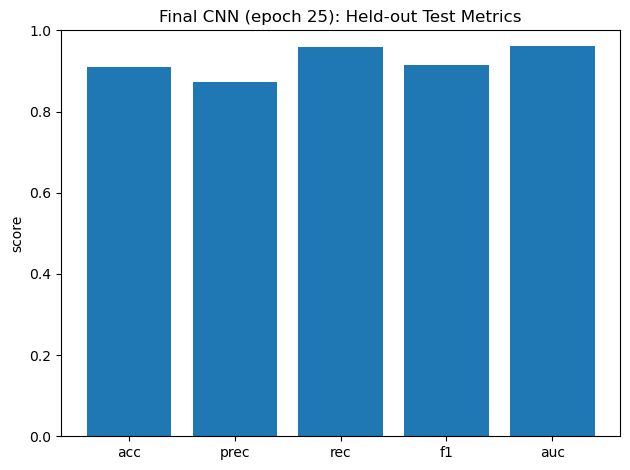

In [75]:
metric_names = ["acc", "prec", "rec", "f1", "auc"]
metric_vals = [final["accuracy"], final["precision"], final["recall"], final["f1"], final["roc_auc"]]

plt.figure()
plt.bar(metric_names, metric_vals)
plt.ylim(0, 1.0)
plt.title("Final CNN (epoch 25): Held-out Test Metrics")
plt.ylabel("score")
plt.tight_layout()
plt.show()

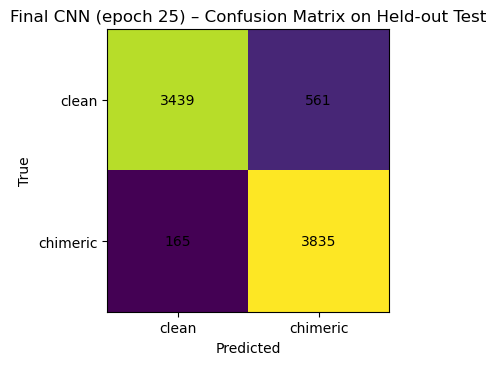

array([[3439,  561],
       [ 165, 3835]])

In [76]:
cm = np.array(final["confusion_matrix"])  # [[TN, FP], [FN, TP]]

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Final CNN (epoch 25) – Confusion Matrix on Held-out Test")
plt.xticks([0, 1], ["clean", "chimeric"])
plt.yticks([0, 1], ["clean", "chimeric"])
plt.xlabel("Predicted")
plt.ylabel("True")

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.tight_layout()
plt.show()

cm

## compare gb vs cnn

In [77]:
tuned_path = Path("../reports/hparam_tuning_pair_noq/tuned_models_summary.tsv")
tuned = pd.read_csv(tuned_path, sep="\t")

gb = tuned[tuned["model"] == "gradient_boosting_tuned"].iloc[0]

compare = pd.DataFrame([
    {"model": "GradientBoosting (tuned)",
     "acc": gb["test_accuracy"], "prec": gb["test_precision"], "rec": gb["test_recall"],
     "f1": gb["test_f1"], "auc": gb["test_roc_auc"]},
    {"model": "CNN1D (final held-out test)",
     "acc": final["accuracy"], "prec": final["precision"], "rec": final["recall"],
     "f1": final["f1"], "auc": final["roc_auc"]},
])

compare

,model,acc,prec,rec,f1,auc
0,GradientBoosting (tuned),0.809053,0.936771,0.66300,0.77646,0.845858
1,CNN1D (final held-out test),0.909250,0.872384,0.95875,0.91353,0.960690


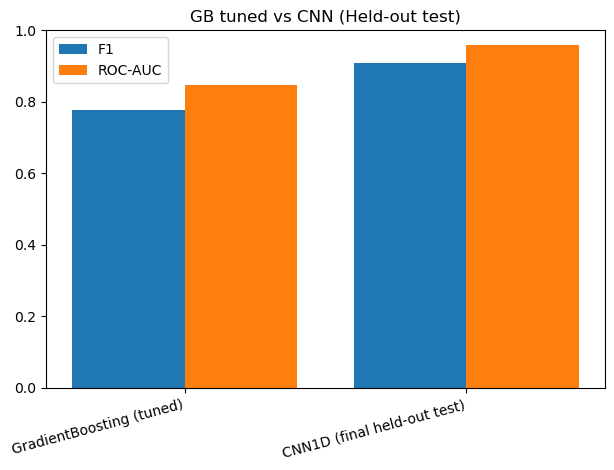

In [46]:
x = np.arange(len(compare))
plt.figure()
plt.bar(x - 0.2, compare["f1"], width=0.4, label="F1")
plt.bar(x + 0.2, compare["auc"], width=0.4, label="ROC-AUC")
plt.xticks(x, compare["model"], rotation=15, ha="right")
plt.ylim(0,1)
plt.title("GB tuned vs CNN (Held-out test)")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
compare.to_csv("../reports/gb_vs_cnn_test.tsv", sep="\t", index=False)
print("Saved:", Path("../reports/gb_vs_cnn_test.tsv"))

Saved: ../reports/gb_vs_cnn_test.tsv
